Fertilizer Scheduling System: Vellaioya Tea Estate

Loading Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from copy import deepcopy
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
plt.style.use('default')

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11
})
PALETTE = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

REF_DATE = pd.Timestamp('2025-09-30')
TODAY = pd.Timestamp.today().normalize()
VP_THRESHOLD = 12.0
SD_THRESHOLD = 10.0

Data Loading, Cleaning and Feature Engineering

Block Metadata (Yield History)

In [32]:
def clean_num(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace(',', '', regex=False)
              .str.replace('-', '', regex=False)
              .str.strip(),
        errors='coerce'
    )


raw = pd.read_csv('Data\Block_Metadata.csv', header=None)
raw = raw.dropna(how='all').reset_index(drop=True).iloc[4:].reset_index(drop=True)

n_yr = raw.shape[1] - 8
raw.columns = (
    ['Division', 'Asst_Manager', 'Field', 'Area', 'Type','Planting_Year', 'Last_Pruned', 'Age_Months']
    + [f'Yield_Yr{i}' for i in range(1, n_yr + 1)]
)

for col in ['Area', 'Age_Months'] + [f'Yield_Yr{i}' for i in range(1, n_yr + 1)]:
    raw[col] = clean_num(raw[col])

raw['Division'] = raw['Division'].ffill().astype(str).str.strip()
raw['Field'] = raw['Field'].astype(str).str.strip()
raw = raw[raw['Field'].notna() & ~raw['Field'].isin(['nan', '0'])].copy()

yr_cols = [f'Yield_Yr{i}' for i in range(2, 7) if f'Yield_Yr{i}' in raw.columns]
raw['Annual_Yield_kgha'] = clean_num(raw['Yield_Yr2'])
raw['Avg5Y_Yield_kgha'] = raw[yr_cols].mean(axis=1)
raw['Yield_Trend'] = raw['Yield_Yr2'] - raw['Yield_Yr3']
raw['Yield_CV'] = raw[yr_cols].std(axis=1) / raw[yr_cols].mean(axis=1)

df_meta = raw[['Division', 'Field', 'Area', 'Age_Months','Annual_Yield_kgha',
               'Avg5Y_Yield_kgha', 'Yield_Trend', 'Yield_CV',
               'Yield_Yr3', 'Yield_Yr4', 'Yield_Yr5']].copy()

print(f'Block Metadata: {len(df_meta)} fields')
df_meta.head()

Block Metadata: 71 fields


,Division,Field,Area,Age_Months,Annual_Yield_kgha,Avg5Y_Yield_kgha,Yield_Trend,Yield_CV,Yield_Yr3,Yield_Yr4,Yield_Yr5
0,LVO,1,4.0,24.0,2036.0,1377.6,1227.0,0.354869,809.0,1069.0,1287.0
1,LVO,2,9.0,17.0,843.0,1137.2,-472.0,0.331264,1315.0,1118.0,1674.0
2,LVO,3,5.0,7.0,967.0,1329.8,-685.0,0.314413,1652.0,1493.0,805.0
3,LVO,3B,5.0,18.0,1120.0,1313.4,-525.0,0.180589,1645.0,1475.0,1106.0
4,LVO,5,7.0,13.0,963.0,1373.0,-646.0,0.274759,1609.0,1344.0,1877.0


Fertilizer History

In [33]:
raw = pd.read_csv('Data\Fertilizer_History.csv', header=None)
raw.columns = ['Division', 'Field', 'Area', 'Type', 'Date', 'Amount', 'Block', 'Extra']
raw = raw.drop(columns=['Extra']).dropna(how='all')
raw['Division'] = raw['Division'].ffill().astype(str).str.strip()
raw = raw[
    raw['Field'].notna()
    & ~raw['Field'].astype(str).isin(['0', '-', 'Field', 'nan'])
    & ~raw['Division'].isin(['Division', '0'])
]
raw['Area']   = clean_num(raw['Area'])
raw['Amount'] = pd.to_numeric(raw['Amount'], errors='coerce')
raw = raw.dropna(subset=['Area', 'Amount'])
raw['Date'] = pd.to_datetime(
    raw['Date'].astype(str).str.replace('Sept', 'Sep', regex=False),
    format='%d-%b-%y', errors='coerce'
)
raw = raw.dropna(subset=['Date'])
raw['Field'] = raw['Field'].astype(str).str.strip()
raw['Dose_Rate_kgha'] = raw['Amount'] / raw['Area']
raw['Fert_Month']     = raw['Date'].dt.strftime('%B')
raw['Fert_Month_Num'] = raw['Date'].dt.month

df_fert = (
    raw.sort_values('Date')
       .groupby(['Division', 'Field'], sort=False)
       .last()
       .reset_index()
)[['Division', 'Field', 'Area', 'Amount', 'Dose_Rate_kgha',
   'Date', 'Fert_Month', 'Fert_Month_Num']]
df_fert = df_fert.rename(columns={'Date': 'Last_Fert_Date'})


print(f'Fertilizer records: {len(raw)} total')
print(f'Amount range: {df_fert["Amount"].min():.0f} - {df_fert["Amount"].max():.0f} kg & mean = {df_fert["Amount"].mean():.1f} kg')
print(f'Amount rate range: {df_fert["Dose_Rate_kgha"].min():.2f} - {df_fert["Dose_Rate_kgha"].max():.2f} kg/ha | mean = {df_fert["Dose_Rate_kgha"].mean():.2f} kg/ha')
df_fert.head()

Fertilizer records: 65 total
Amount range: 5 - 47 kg & mean = 23.1 kg
Amount rate range: 0.67 - 28.00 kg/ha | mean = 5.75 kg/ha


,Division,Field,Area,Amount,Dose_Rate_kgha,Last_Fert_Date,Fert_Month,Fert_Month_Num
0,UVO,17,4.0,47,11.750000,2021-08-31,August,8
1,LDK,51,3.0,47,15.666667,2021-08-31,August,8
2,UVO,12,4.0,41,10.250000,2022-02-25,February,2
3,UDK,29,4.0,41,10.250000,2022-02-26,February,2
4,LVO,6,6.0,41,6.833333,2022-02-28,February,2


Climate Data

In [34]:
raw = pd.read_csv('Data\Climate_Data.csv', header=None).dropna(how='all').reset_index(drop=True)
months = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']
raw = raw[raw[0].astype(str).str.strip().isin(months)].reset_index(drop=True)

nc   = raw.shape[1]
cols = ['Month']
for i in range((nc - 1) // 2):
    cols += [f'Wetdays_Yr{i+1}', f'Rainfall_Yr{i+1}']
if len(cols) < nc:
    cols += [f'Extra_{i}' for i in range(len(cols), nc)]
raw.columns = cols[:nc]

for col in raw.columns[1:]:
    raw[col] = clean_num(raw[col])
raw = raw[[c for c in raw.columns if raw[c].notna().sum() > 0 or c == 'Month']]

raw['Rainfall_Mean'] = raw[[c for c in raw.columns if 'Rainfall' in c]].mean(axis=1)
raw['Rainfall_Max']  = raw[[c for c in raw.columns if 'Rainfall' in c]].max(axis=1)
raw['Wetdays_Mean']  = raw[[c for c in raw.columns if 'Wetdays'  in c]].mean(axis=1)

df_climate = raw[['Month', 'Rainfall_Mean', 'Rainfall_Max', 'Wetdays_Mean']].copy()
print(f'Climate: {len(df_climate)} months')
df_climate

Climate: 12 months


,Month,Rainfall_Mean,Rainfall_Max,Wetdays_Mean
0,April,324.600000,595.0,15.400000
1,May,844.090909,1352.0,21.454545
2,June,589.545455,1041.0,22.727273
3,July,602.636364,825.0,20.636364
4,August,813.818182,1393.0,18.909091
5,September,490.636364,845.0,19.363636
6,October,626.636364,1166.0,21.818182
7,November,445.800000,895.0,17.700000
8,December,224.800000,285.0,10.200000
9,January,77.444444,154.0,7.222222


Plucking Rounds (Aug 2025)

In [35]:
raw = pd.read_csv('Data\Last 10 Year Data - PLUCKING ROUNDS -AS AT AUG-25.csv', header=None)
raw.columns = ['Field', 'Type', 'Extent', 'Rounds_2526', 'Rounds_2425', 'Rounds_2324']

div_map = {
    'AGROYA DIVISION': 'AGO',
    'LOWER DANDUKELLEWA DIVISION':'LDK',
    'LOWER VELLAI OYA DIVISION':'LVO',
    'UPPER DANDUKELLEWA DIVISION':'UDK',
    'UPPER VELLAI OYA DIVISION': 'UVO',
}
raw['Division'] = raw['Field'].map(div_map).ffill()
raw = raw[~raw['Field'].astype(str).str.contains(
    'Division|Estate|PLUCKING|Field|Type', na=True)].copy()
raw = raw[raw['Field'].notna()].copy()

for col in ['Rounds_2526', 'Rounds_2425', 'Rounds_2324', 'Extent']:
    raw[col] = pd.to_numeric(
        raw[col].astype(str).str.strip().replace('-', ''), errors='coerce')
raw['Field'] = raw['Field'].astype(str).str.strip()

raw['Rounds_2Y_Mean'] = raw[['Rounds_2324', 'Rounds_2425']].mean(axis=1)
raw['Rounds_Trend'] = raw['Rounds_2425'] - raw['Rounds_2324']

df_pluck = raw[['Division', 'Field', 'Rounds_2324', 'Rounds_2425','Rounds_2Y_Mean', 'Rounds_Trend']].copy()
print(f'Plucking Rounds: {len(df_pluck)} fields')
df_pluck.head()

Plucking Rounds: 70 fields


,Division,Field,Rounds_2324,Rounds_2425,Rounds_2Y_Mean,Rounds_Trend
4,AGO,AGROYA DIVISION,NaN,NaN,NaN,NaN
5,AGO,3A,29.0,29.0,29.0,0.0
6,AGO,3B,22.0,31.0,26.5,9.0
7,AGO,4A,30.0,21.0,25.5,-9.0
8,AGO,9G,30.0,24.0,27.0,-6.0


Plucking Rounds September 2025 

In [36]:
raw = pd.read_csv('Data\Last 10 Year Data -  Plucking Rounds month of September 2025 .csv',
    header=None)
ds = raw.iloc[6:].copy()
ds.columns = [
    'Division', 'Months_After_Pruning', 'Field', 'Extent_Ha', 'VP_SD',
    'Last_Pruned', 'MAP2', 'Month_Yield_kgha', 'N_Ratio_12Mon',
    'N_Ratio_Seas', 'Plucking_Rounds_Sep', 'Remarks', 'Field2'
]
ds['Division'] = ds['Division'].ffill().astype(str).str.strip()
ds = ds[pd.to_numeric(ds['Extent_Ha'], errors='coerce').notna()].copy()
ds['Field'] = ds['Field'].astype(str).str.strip()
ds = ds[ds['Field'].notna() & ds['Field'].ne('nan')].copy()

for col in ['Extent_Ha', 'N_Ratio_12Mon', 'N_Ratio_Seas',
            'Month_Yield_kgha', 'Months_After_Pruning']:
    ds[col] = pd.to_numeric(
        ds[col].astype(str).str.replace('-', '', regex=False).str.strip(),
        errors='coerce')

ds['Last_Pruned'] = pd.to_datetime(ds['Last_Pruned'], errors='coerce', dayfirst=True)
ds['VP_SD'] = ds['VP_SD'].astype(str).str.strip().str.upper()
ds['Seasonal_Yield_kgha'] = ds['Month_Yield_kgha'] * ds['Months_After_Pruning']
ds['N_Threshold'] = np.where(ds['VP_SD'] == 'SD', SD_THRESHOLD, VP_THRESHOLD)
ds['Fert_Needed']= ds['N_Ratio_Seas'] < ds['N_Threshold']

df_sep = ds[[
    'Division', 'Field', 'VP_SD', 'Extent_Ha', 'Last_Pruned',
    'Months_After_Pruning', 'Month_Yield_kgha', 'Seasonal_Yield_kgha',
    'N_Ratio_12Mon', 'N_Ratio_Seas', 'N_Threshold', 'Fert_Needed'
]].reset_index(drop=True)

print(f'Sep 2025: {len(df_sep)} fields | VP: {(df_sep["VP_SD"]=="VP").sum()} | SD: {(df_sep["VP_SD"]=="SD").sum()}')
print(f'Fields with N-ratio below threshold: {df_sep["Fert_Needed"].sum()}')
df_sep.head()

Sep 2025: 65 fields | VP: 64 | SD: 1
Fields with N-ratio below threshold: 4


,Division,Field,VP_SD,Extent_Ha,Last_Pruned,Months_After_Pruning,Month_Yield_kgha,Seasonal_Yield_kgha,N_Ratio_12Mon,N_Ratio_Seas,N_Threshold,Fert_Needed
0,LVO,6,VP,6.0,2025-08-12,1,NaN,NaN,124.03,29.76,12.0,False
1,LVO,9B,VP,5.0,2025-02-28,6,56.0,336.0,66.67,20.45,12.0,False
2,LVO,3,VP,5.0,2025-02-10,7,73.0,511.0,126.98,33.24,12.0,False
3,LVO,8,VP,8.5,2024-08-29,12,99.0,1188.0,24.58,18.29,12.0,False
4,LVO,5,VP,7.0,2024-08-19,13,102.0,1326.0,23.46,20.48,12.0,False


Merging All Datasets

In [37]:
master = df_sep.copy()
master = master.merge(df_meta, on=['Division', 'Field'], how='left')
master = master.merge(df_pluck, on=['Division', 'Field'], how='left')
master = master.merge(
    df_fert[['Division', 'Field', 'Dose_Rate_kgha','Last_Fert_Date', 'Fert_Month', 'Fert_Month_Num']],
    on=['Division', 'Field'], how='left'
)

fert_month = master['Fert_Month'].fillna('September')
master = master.merge(
    df_climate.rename(columns={
        'Rainfall_Mean':'App_Rainfall_Mean',
        'Rainfall_Max':'App_Rainfall_Max',
        'Wetdays_Mean':'App_Wetdays_Mean'
    }),
    left_on=fert_month, right_on='Month', how='left'
)

sep_row = df_climate[df_climate['Month'] == 'September'].iloc[0]
master['Sep_Rainfall'] = sep_row['Rainfall_Mean']
master['Sep_Wetdays'] = sep_row['Wetdays_Mean']
master['Apps_Per_Year'] = np.clip(master['Rounds_2Y_Mean'] / 8.0, 3.0, 4.0)
master['Cycle_Days_Target'] = (365 / master['Apps_Per_Year']).round(0).clip(90, 120).astype(int)

le_d = LabelEncoder()
le_t = LabelEncoder()
master['Division_enc'] = le_d.fit_transform(master['Division'].astype(str))
master['VP_SD_enc'] = le_t.fit_transform(master['VP_SD'].astype(str))

fill_cols = [
    'Annual_Yield_kgha', 'Avg5Y_Yield_kgha', 'Yield_Trend', 'Yield_CV',
    'Age_Months', 'Rounds_2324', 'Rounds_2425', 'Rounds_2Y_Mean', 'Rounds_Trend',
    'Dose_Rate_kgha', 'App_Rainfall_Mean', 'App_Rainfall_Max',
    'App_Wetdays_Mean', 'Yield_Yr3', 'Yield_Yr4', 'Yield_Yr5', 'Fert_Month_Num',
]
for col in fill_cols:
    master[col] = master[col].fillna(master[col].median())
master['Month_Yield_kgha'] = master['Month_Yield_kgha'].fillna(0)
master['N_Ratio_12Mon'] = master['N_Ratio_12Mon'].fillna(master['N_Ratio_Seas'])
master['Seasonal_Yield_kgha'] = master['Seasonal_Yield_kgha'].fillna(0)

print(f'Master dataset: {master.shape[0]} fields x {master.shape[1]} columns')
master.head()

Master dataset: 65 fields x 39 columns


,Division,Field,VP_SD,Extent_Ha,Last_Pruned,Months_After_Pruning,Month_Yield_kgha,Seasonal_Yield_kgha,N_Ratio_12Mon,N_Ratio_Seas,...,Month,App_Rainfall_Mean,App_Rainfall_Max,App_Wetdays_Mean,Sep_Rainfall,Sep_Wetdays,Apps_Per_Year,Cycle_Days_Target,Division_enc,VP_SD_enc
0,LVO,6,VP,6.0,2025-08-12,1,0.0,0.0,124.03,29.76,...,February,96.000000,202.0,6.142857,490.636364,19.363636,3.1250,117,2,1
1,LVO,9B,VP,5.0,2025-02-28,6,56.0,336.0,66.67,20.45,...,February,96.000000,202.0,6.142857,490.636364,19.363636,3.1875,115,2,1
2,LVO,3,VP,5.0,2025-02-10,7,73.0,511.0,126.98,33.24,...,February,96.000000,202.0,6.142857,490.636364,19.363636,3.0000,120,2,1
3,LVO,8,VP,8.5,2024-08-29,12,99.0,1188.0,24.58,18.29,...,August,813.818182,1393.0,18.909091,490.636364,19.363636,3.0000,120,2,1
4,LVO,5,VP,7.0,2024-08-19,13,102.0,1326.0,23.46,20.48,...,August,813.818182,1393.0,18.909091,490.636364,19.363636,3.0000,120,2,1


Exploratory Data Analysis

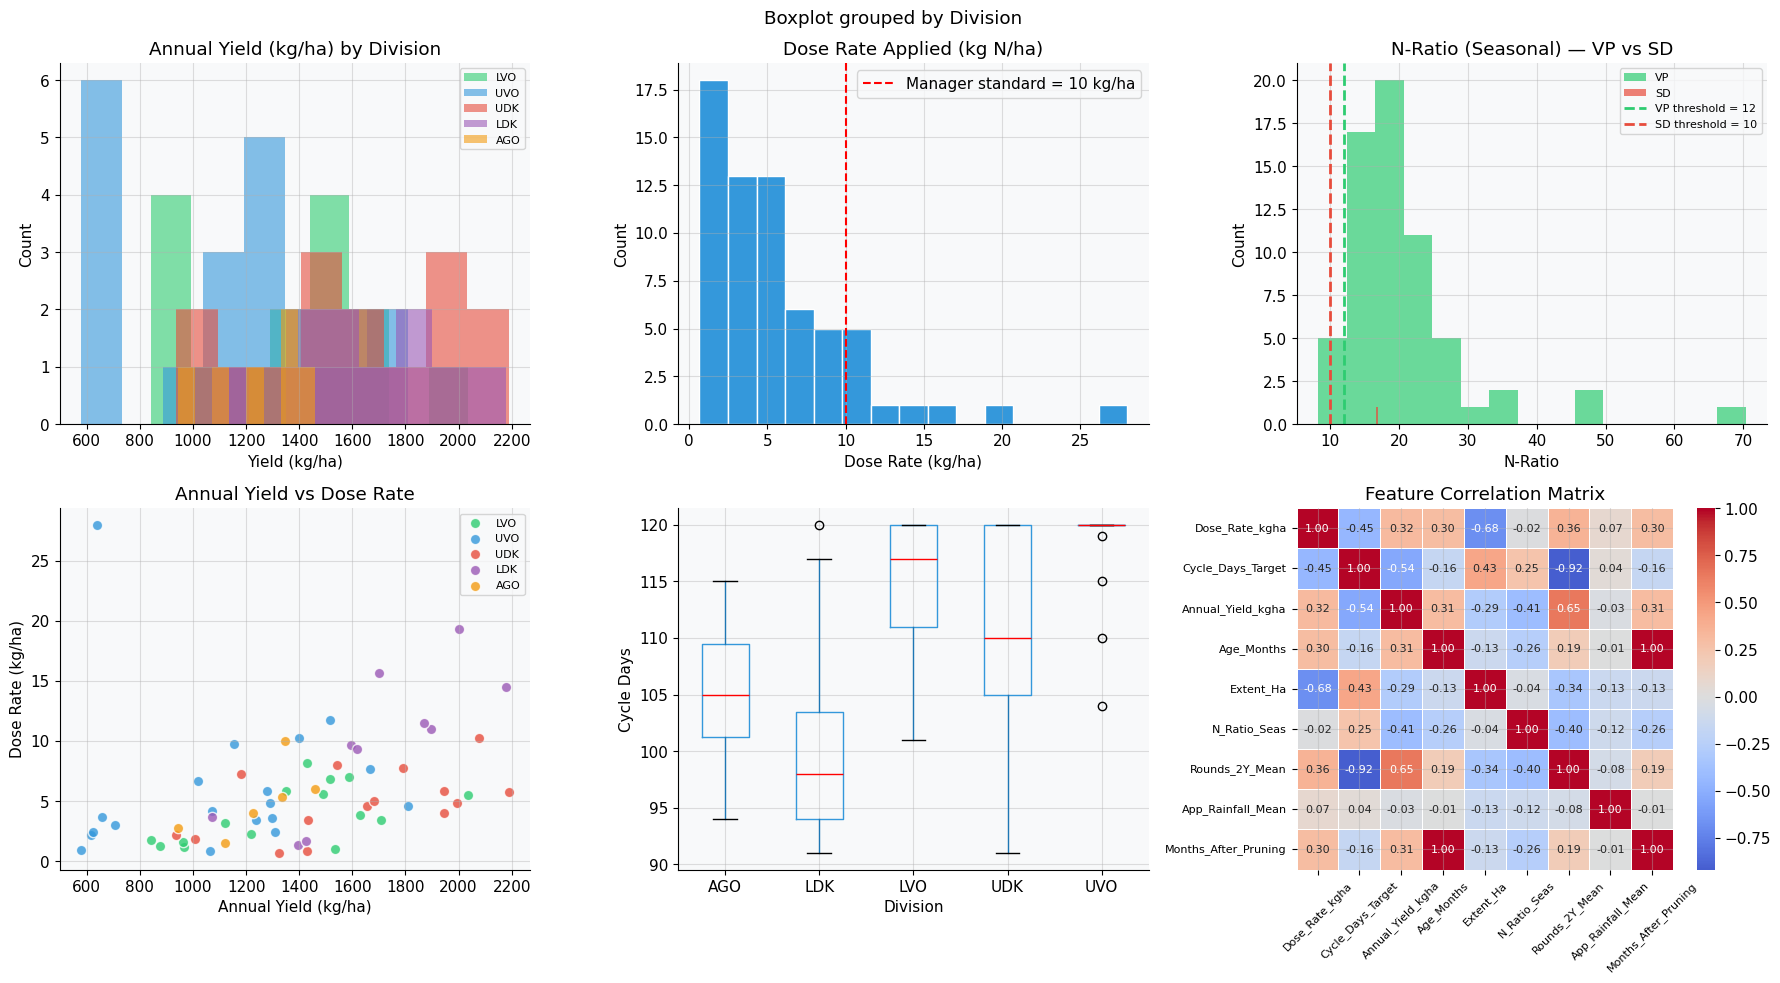

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis — Vellaioya Estate', fontsize=14, fontweight='bold')

div_colors = dict(zip(master['Division'].unique(), PALETTE))

ax = axes[0, 0]
for div in master['Division'].unique():
    ax.hist(master[master['Division'] == div]['Annual_Yield_kgha'].dropna(),
            bins=8, alpha=0.6, label=div, color=div_colors[div])
ax.set_title('Annual Yield (kg/ha) by Division')
ax.set_xlabel('Yield (kg/ha)'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.hist(master['Dose_Rate_kgha'].dropna(), bins=15, color='#3498db', edgecolor='white')
ax.axvline(10, color='red', linestyle='--', label='Manager standard = 10 kg/ha')
ax.set_title('Dose Rate Applied (kg N/ha)')
ax.set_xlabel('Dose Rate (kg/ha)'); ax.set_ylabel('Count'); ax.legend()

ax = axes[0, 2]
ax.hist(master[master['VP_SD'] == 'VP']['N_Ratio_Seas'].dropna(),
        bins=15, alpha=0.7, label='VP', color='#2ecc71')
ax.hist(master[master['VP_SD'] == 'SD']['N_Ratio_Seas'].dropna(),
        bins=5, alpha=0.7, label='SD', color='#e74c3c')
ax.axvline(12, color='#2ecc71', linestyle='--', linewidth=2, label='VP threshold = 12')
ax.axvline(10, color='#e74c3c', linestyle='--', linewidth=2, label='SD threshold = 10')
ax.set_title('N-Ratio (Seasonal) — VP vs SD')
ax.set_xlabel('N-Ratio'); ax.set_ylabel('Count'); ax.legend(fontsize=8)

ax = axes[1, 0]
for div in master['Division'].unique():
    sub = master[master['Division'] == div]
    ax.scatter(sub['Annual_Yield_kgha'], sub['Dose_Rate_kgha'],
               label=div, color=div_colors[div], alpha=0.8, s=55, edgecolors='white')
ax.set_title('Annual Yield vs Dose Rate')
ax.set_xlabel('Annual Yield (kg/ha)'); ax.set_ylabel('Dose Rate (kg/ha)'); ax.legend(fontsize=8)

ax = axes[1, 1]
master.boxplot(column='Cycle_Days_Target', by='Division', ax=ax,
               boxprops=dict(color='#3498db'), medianprops=dict(color='red'))
ax.set_title('Application Cycle Target by Division')
ax.set_xlabel('Division'); ax.set_ylabel('Cycle Days')
plt.sca(ax); plt.title('')

ax = axes[1, 2]
corr_cols = ['Dose_Rate_kgha', 'Cycle_Days_Target', 'Annual_Yield_kgha',
             'Age_Months', 'Extent_Ha', 'N_Ratio_Seas', 'Rounds_2Y_Mean',
             'App_Rainfall_Mean', 'Months_After_Pruning']
sns.heatmap(master[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

Feature Engineering and Train / Test Split

In [39]:
FEAT_AMT = [
    'Extent_Ha', 'Age_Months', 'Annual_Yield_kgha', 'Avg5Y_Yield_kgha',
    'Yield_Trend', 'Yield_CV', 'Yield_Yr3', 'Yield_Yr4',
    'Months_After_Pruning', 'Month_Yield_kgha', 'Seasonal_Yield_kgha',
    'N_Ratio_Seas', 'N_Ratio_12Mon',
    'Rounds_2Y_Mean', 'Rounds_Trend',
    'App_Rainfall_Mean', 'App_Wetdays_Mean',
    'Fert_Month_Num', 'Division_enc', 'VP_SD_enc'
]

FEAT_DAYS = [
    'Extent_Ha', 'Age_Months', 'Annual_Yield_kgha', 'Avg5Y_Yield_kgha',
    'Yield_Trend', 'Yield_Yr3', 'Yield_Yr4',
    'Months_After_Pruning', 'Month_Yield_kgha', 'Seasonal_Yield_kgha',
    'N_Ratio_Seas', 'N_Ratio_12Mon', 'Rounds_Trend',
    'App_Rainfall_Mean', 'App_Wetdays_Mean', 'Sep_Rainfall', 'Sep_Wetdays',
    'Fert_Month_Num', 'Division_enc', 'VP_SD_enc'
]

X_amt  = master[FEAT_AMT].fillna(master[FEAT_AMT].median())
X_days = master[FEAT_DAYS].fillna(master[FEAT_DAYS].median())
y_amt  = master['Dose_Rate_kgha']
y_days = master['Cycle_Days_Target']  

X_amt_tr, X_amt_te, y_amt_tr, y_amt_te = train_test_split(
    X_amt, y_amt, test_size=0.20, random_state=42,
    stratify=master['Division_enc']
)
X_days_tr, X_days_te, y_days_tr, y_days_te = train_test_split(
    X_days, y_days, test_size=0.20, random_state=42,
    stratify=master['Division_enc']
)

scaler_amt  = StandardScaler()
scaler_days = StandardScaler()

X_amt_tr_sc  = scaler_amt.fit_transform(X_amt_tr)
X_amt_te_sc  = scaler_amt.transform(X_amt_te)
X_days_tr_sc = scaler_days.fit_transform(X_days_tr)
X_days_te_sc = scaler_days.transform(X_days_te)

print(f'Samples: {len(X_amt_te)} test, {len(X_amt_tr)} total')
print(f'Amount (dose rate) target: {y_amt.min():.2f} - {y_amt.max():.2f} kg/ha | mean = {y_amt.mean():.2f} kg/ha')
print(f'Cycle_Days_Target: {y_days.min():.0f} - {y_days.max():.0f} days | mean = {y_days.mean():.1f} days')

Samples: 13 test, 52 total
Amount (dose rate) target: 0.67 - 28.00 kg/ha | mean = 5.75 kg/ha
Cycle_Days_Target: 91 - 120 days | mean = 111.8 days


Model 1:  Fertilizer Amount Rate (kg N/ha)

In [40]:
gb_amt = GradientBoostingRegressor(
    n_estimators=150,
    max_depth=3,
    min_samples_leaf=4,
    learning_rate=0.08,
    random_state=42
)
gb_amt.fit(X_amt_tr_sc, y_amt_tr)

y_amt_te_pred = gb_amt.predict(X_amt_te_sc)

test_r2_amt  = r2_score(y_amt_te, y_amt_te_pred)
test_mae_amt = mean_absolute_error(y_amt_te, y_amt_te_pred)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(gb_amt, X_amt_tr_sc, y_amt_tr, cv=kf, scoring='r2')
cv_mae = cross_val_score(gb_amt, X_amt_tr_sc, y_amt_tr,
                          cv=kf, scoring='neg_mean_absolute_error')
print('Model 1 : Fertilizer Amount Rate (kg N/ha)')
print(f'R^2  : {test_r2_amt:.4f}')
print(f'MAE : {test_mae_amt:.4f} kg/ha')


Model 1 : Fertilizer Amount Rate (kg N/ha)
R^2  : 0.8497
MAE : 1.2529 kg/ha


Model 2: Application Interval (Cycle Days)

In [41]:
rf_days = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)
rf_days.fit(X_days_tr_sc, y_days_tr)

y_days_te_pred = rf_days.predict(X_days_te_sc)

test_r2_days  = r2_score(y_days_te, y_days_te_pred)
test_mae_days = mean_absolute_error(y_days_te, y_days_te_pred)

cv_r2_d  = cross_val_score(rf_days, X_days_tr_sc, y_days_tr, cv=kf, scoring='r2')
cv_mae_d = cross_val_score(rf_days, X_days_tr_sc, y_days_tr,
                            cv=kf, scoring='neg_mean_absolute_error')

print('Model 2: Fertilizer Application Interval (Cycle Days Target)')
print(f'R^2  : {test_r2_days:.4f}')
print(f'MAE : {test_mae_days:.4f} days')

Model 2: Fertilizer Application Interval (Cycle Days Target)
R^2  : 0.6320
MAE : 3.9759 days


Scatter Plot

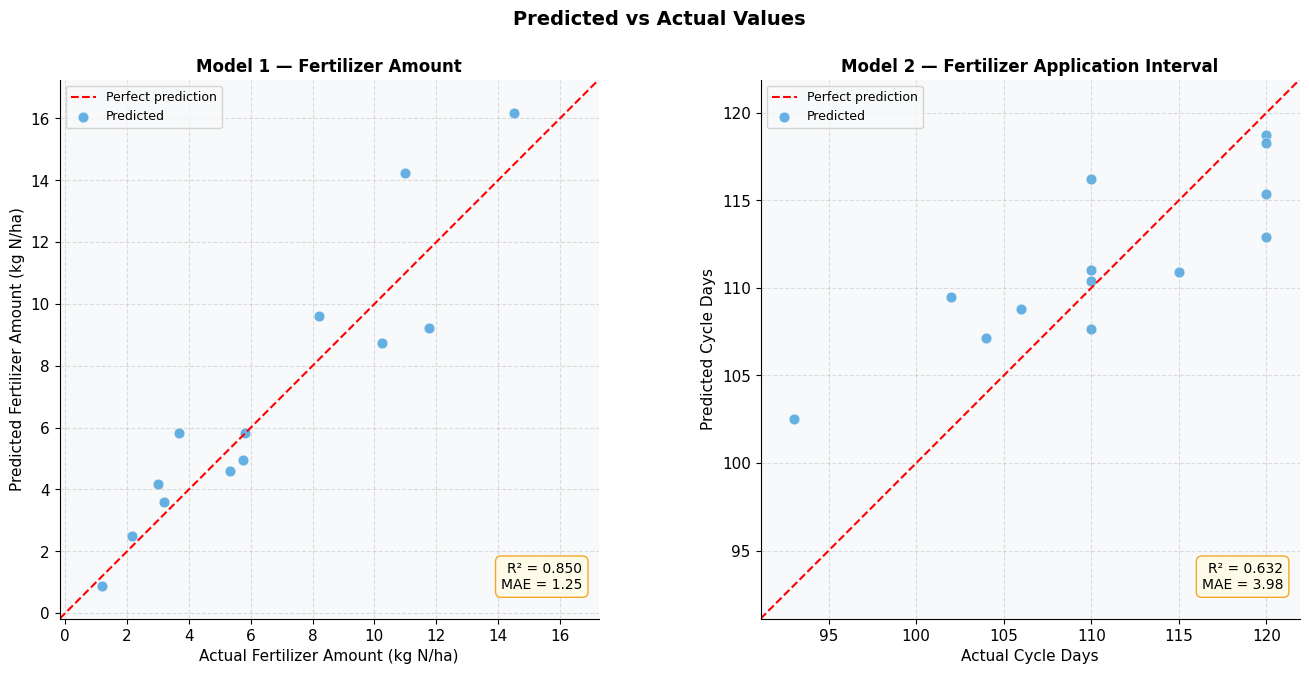

In [42]:
fig = plt.figure(figsize=(16, 7))
fig.suptitle('Predicted vs Actual Values', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)


def scatter_panel(ax, y_true, y_pred, title, unit):
    lo  = min(y_true.min(), y_pred.min())
    hi  = max(y_true.max(), y_pred.max())
    pad = (hi - lo) * 0.07

    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
    ax.scatter(y_true, y_pred, color='#3498db', alpha=0.75, s=60,
               edgecolors='white', linewidth=0.5, label='Predicted')

    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f'Actual {unit}', fontsize=11)
    ax.set_ylabel(f'Predicted {unit}', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal', adjustable='box')

    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    ax.text(0.97, 0.05, f'R² = {r2:.3f}\nMAE = {mae:.2f}',
            transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#fffde7',
                      edgecolor='#f39c12', alpha=0.9))
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)


ax1 = fig.add_subplot(gs[0])
scatter_panel(ax1, y_amt_te.values, y_amt_te_pred,
              'Model 1 — Fertilizer Amount', 'Fertilizer Amount (kg N/ha)')

ax2 = fig.add_subplot(gs[1])
scatter_panel(ax2, y_days_te.values, y_days_te_pred,
              'Model 2 — Fertilizer Application Interval', 'Cycle Days')

plt.show()

Fertilizer Schedule

In [43]:
X_amt_all  = scaler_amt.transform(X_amt)
X_days_all = scaler_days.transform(X_days)

master['Pred_Dose_kgha']  = gb_amt.predict(X_amt_all).clip(1.0, 15.0).round(2)
master['Pred_Amount_kg']  = (master['Pred_Dose_kgha'] * master['Extent_Ha']).round(0).astype(int)
master['Pred_Cycle_Days'] = rf_days.predict(X_days_all).clip(90, 120).round(0).astype(int)

next_dates, last_dates, days_till = [], [], []
for _, row in master.iterrows():
    anchor = row['Last_Fert_Date'] if pd.notna(row.get('Last_Fert_Date')) else REF_DATE
    cycle  = int(row['Pred_Cycle_Days'])
    nxt    = anchor + pd.Timedelta(days=cycle)
    lst    = anchor
    while nxt < TODAY:
        lst = nxt
        nxt += pd.Timedelta(days=cycle)
    last_dates.append(lst)
    next_dates.append(nxt)
    days_till.append((nxt - TODAY).days)

master['Last_App_Date']   = last_dates
master['Next_App_Date']   = next_dates
master['Days_Until_Next'] = days_till

master['Schedule_Status'] = master['Days_Until_Next'].apply(
    lambda d: 'OVERDUE'   if d <  0 else
              'DUE TODAY' if d == 0 else
              'DUE SOON'  if d <= 30 else
              'UPCOMING'
)
master['Priority_Flag'] = np.where(
    master['Fert_Needed'] & (master['Days_Until_Next'] > 0),
    'N-RATIO LOW - apply early', ''
)

schedule = master[[
    'Division', 'Field', 'VP_SD', 'Extent_Ha',
    'N_Ratio_Seas', 'N_Threshold', 'Fert_Needed',
    'Annual_Yield_kgha', 'Pred_Dose_kgha', 'Pred_Amount_kg', 'Pred_Cycle_Days',
    'Last_App_Date', 'Next_App_Date',
    'Days_Until_Next', 'Schedule_Status', 'Priority_Flag'
]].copy()

schedule['Last_App_Date'] = pd.to_datetime(schedule['Last_App_Date']).dt.strftime('%Y-%m-%d')
schedule['Next_App_Date'] = pd.to_datetime(schedule['Next_App_Date']).dt.strftime('%Y-%m-%d')
schedule['N_Ratio_Seas']  = schedule['N_Ratio_Seas'].round(2)
schedule = schedule.sort_values('Days_Until_Next').reset_index(drop=True)

print(f'FERTILIZER SCHEDULE — Vellaioya Estate | Run date: {TODAY.date()}')
print('-' * 220)
print(schedule.to_string(index=False))

print('\n--- Summary ---')
for status in ['OVERDUE', 'DUE TODAY', 'DUE SOON', 'UPCOMING']:
    n = (schedule['Schedule_Status'] == status).sum()
    if n:
        print(f'{status:<14}: {n} fields')

print(f'\nPredicted dose range: {schedule["Pred_Dose_kgha"].min():.1f} - {schedule["Pred_Dose_kgha"].max():.1f} kg/ha')
print(f'Predicted amount range: {schedule["Pred_Amount_kg"].min()} - {schedule["Pred_Amount_kg"].max()} kg')
print(f'Predicted cycle range: {schedule["Pred_Cycle_Days"].min()} - {schedule["Pred_Cycle_Days"].max()} days')
print(f'Last_App_Date all before today: {all(pd.to_datetime(schedule["Last_App_Date"]) < TODAY)}')
print(f'Next_App_Date all today or later: {all(pd.to_datetime(schedule["Next_App_Date"]) >= TODAY)}')

print('\n--- Fields with N-ratio below threshold ---')
ratio_now = schedule[schedule['Fert_Needed']]
if ratio_now.empty:
    print('All fields within acceptable N-ratio range')
else:
    print(ratio_now[[
        'Division', 'Field', 'VP_SD', 'N_Ratio_Seas', 'N_Threshold',
        'Pred_Amount_kg', 'Next_App_Date', 'Priority_Flag'
    ]].to_string(index=False))

FERTILIZER SCHEDULE — Vellaioya Estate | Run date: 2026-05-31
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Division Field VP_SD  Extent_Ha  N_Ratio_Seas  N_Threshold  Fert_Needed  Annual_Yield_kgha  Pred_Dose_kgha  Pred_Amount_kg  Pred_Cycle_Days Last_App_Date Next_App_Date  Days_Until_Next Schedule_Status             Priority_Flag
     LDK    47    VP       1.50         14.55         12.0        False             2001.0           15.00              22               99    2026-02-21    2026-05-31                0       DUE TODAY                          
     LDK    46    VP       3.00         14.93         12.0        False             1596.0           10.34              31               99    2026-02-21    2026-05-31                0       DUE TODAY                          
     LDK    53    VP       2.00     

Model Comparison

In [44]:
MODEL_DEFS = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=3,
                             min_samples_leaf=4, learning_rate=0.08, random_state=42),

    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6,
                             min_samples_leaf=3, max_features='sqrt', random_state=42),

    'Decision Tree': DecisionTreeRegressor(max_depth=5, min_samples_leaf=4, random_state=42),

    'Neural Net (MLP)': MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=3000,
                             early_stopping=True, random_state=42, alpha=0.01),

    'Ridge Regression': Ridge(alpha=1.0),
}

results = {}
for name, proto in MODEL_DEFS.items():
    m_amt  = deepcopy(proto)
    m_days = deepcopy(proto)

    m_amt.fit(X_amt_tr_sc, y_amt_tr)
    m_days.fit(X_days_tr_sc, y_days_tr)

    amt_test_r2  = r2_score(y_amt_te,  m_amt.predict(X_amt_te_sc))
    amt_mae      = mean_absolute_error(y_amt_te, m_amt.predict(X_amt_te_sc))

    days_test_r2 = r2_score(y_days_te, m_days.predict(X_days_te_sc))
    days_mae     = mean_absolute_error(y_days_te, m_days.predict(X_days_te_sc))

    results[name] = {
        'amt_test_r2': amt_test_r2,
        'amt_mae': amt_mae,
        'days_test_r2': days_test_r2,
        'days_mae': days_mae,
    }

header = f'{"Model":<22}  {"Amount":^22}  {"Cycle Days":^22}'
subhdr = f'{"":<22}  {"R^2":>7} {"MAE (kg/ha)":>13}  {"R^2":>7} {"MAE (days)":>13}'
print(header)
print(subhdr)
print('-' * 80)

for name, r in results.items():
    print(f'{name:<22}  {r["amt_test_r2"]:>7.4f} {r["amt_mae"]:>13.4f}  '
          f'{r["days_test_r2"]:>7.4f} {r["days_mae"]:>13.2f}')

Model                           Amount                Cycle Days      
                            R^2   MAE (kg/ha)      R^2    MAE (days)
--------------------------------------------------------------------------------
Gradient Boosting        0.8497        1.2529   0.4725          4.66
Random Forest            0.8159        1.2136   0.6320          3.98
Decision Tree            0.3172        2.5300   0.1268          5.62
Neural Net (MLP)         0.5373        2.3542  -2.0924         11.80
Ridge Regression         0.5448        2.2549   0.7451          3.03
